<a href="https://colab.research.google.com/github/trialdyk/marchine-learning/blob/main/JS04/JS04_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Lab - Medical Cost Personal Datasets
## JS04 - Regresi

Analisis regresi biaya medis personal: Multiple Linear Regression dan SVR.

**Dataset:** `insurance.csv` (1338 data)

**Variabel:**
- `age` — umur penerima
- `sex` — jenis kelamin
- `bmi` — Body Mass Index
- `children` — jumlah anak
- `smoker` — perokok atau bukan
- `region` — area pemukiman
- `charges` — biaya medis (target)

## 1. Identifikasi Variabel

Variabel bebas (fitur): `age`, `sex`, `bmi`, `children`, `smoker`, `region`. Variabel target: `charges`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
data.info()
print()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB



,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


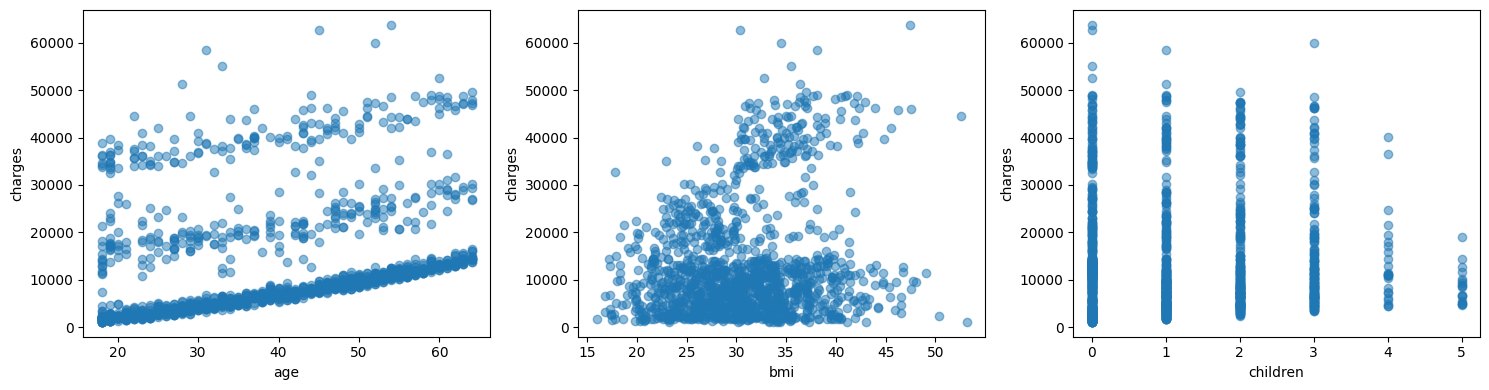

In [3]:
# scatter plot fitur numerik terhadap charges
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(data['age'], data['charges'], alpha=0.5); ax[0].set_xlabel('age'); ax[0].set_ylabel('charges')
ax[1].scatter(data['bmi'], data['charges'], alpha=0.5); ax[1].set_xlabel('bmi'); ax[1].set_ylabel('charges')
ax[2].scatter(data['children'], data['charges'], alpha=0.5); ax[2].set_xlabel('children'); ax[2].set_ylabel('charges')
plt.tight_layout()
plt.show()

In [4]:
# encoding variabel kategorikal
data_enc = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True)
data_enc.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## 2. Bagi Data Latih dan Uji

Proporsi 70:30.

In [5]:
from sklearn.model_selection import train_test_split

X = data_enc.drop(columns=['charges'])
y = data_enc['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (936, 8) Test: (402, 8)


## 3. Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.transform(X_test)

## 4-5. Multiple Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred_linreg = linreg.predict(X_test_scaled)

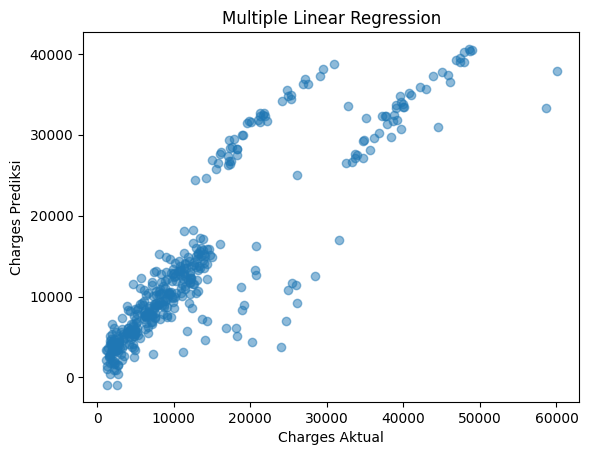

In [8]:
# visualisasi prediksi vs aktual
plt.scatter(y_test, y_pred_linreg, alpha=0.5)
plt.xlabel('Charges Aktual')
plt.ylabel('Charges Prediksi')
plt.title('Multiple Linear Regression')
plt.show()

## 6. Evaluasi Multiple Linear Regression

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_linreg)
mse_lr = mean_squared_error(y_test, y_pred_linreg)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_linreg)

print('=== Multiple Linear Regression ===')
print('MAE :', mae_lr)
print('MSE :', mse_lr)
print('RMSE:', rmse_lr)
print('R2  :', r2_lr)

=== Multiple Linear Regression ===
MAE : 3943.2377039473017
MSE : 32345536.74852545
RMSE: 5687.313667147738
R2  : 0.7772310511733103


## 7. SVR + Hyperparameter Tuning

In [10]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)

In [11]:
# baseline SVR tanpa tuning
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print('=== SVR (baseline) ===')
print('MAE :', mae_svr)
print('MSE :', mse_svr)
print('RMSE:', rmse_svr)
print('R2  :', r2_svr)

=== SVR (baseline) ===
MAE : 8315.756600765373
MSE : 162785273.81306434
RMSE: 12758.733237005323
R2  : -0.121128538188638


In [12]:
# hyperparameter tuning dengan GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [10, 100, 1000],
    'gamma': [0.01, 0.1, 1],
    'epsilon': [0.01, 0.1, 1]
}

grid = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print('Parameter terbaik:', grid.best_params_)
print('Skor CV terbaik:', grid.best_score_)

Parameter terbaik: {'C': 1000, 'epsilon': 1, 'gamma': 0.1}
Skor CV terbaik: 0.6613570874002


In [13]:
# evaluasi SVR hasil tuning
best_svr = grid.best_estimator_
y_pred_svr_tuned = best_svr.predict(X_test_scaled)

mae_svr_t = mean_absolute_error(y_test, y_pred_svr_tuned)
mse_svr_t = mean_squared_error(y_test, y_pred_svr_tuned)
rmse_svr_t = np.sqrt(mse_svr_t)
r2_svr_t = r2_score(y_test, y_pred_svr_tuned)

print('=== SVR (tuned) ===')
print('MAE :', mae_svr_t)
print('MSE :', mse_svr_t)
print('RMSE:', rmse_svr_t)
print('R2  :', r2_svr_t)

=== SVR (tuned) ===
MAE : 2878.9658958261466
MSE : 38116845.65921606
RMSE: 6173.884163086967
R2  : 0.7374831122417584


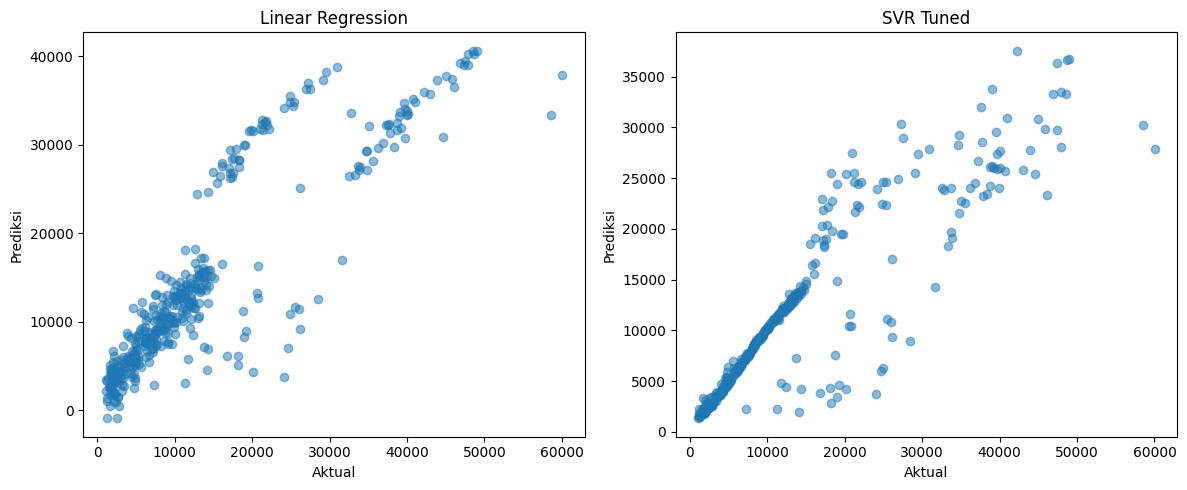

In [14]:
# perbandingan kedua model
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_linreg, alpha=0.5)
plt.xlabel('Aktual'); plt.ylabel('Prediksi'); plt.title('Linear Regression')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_svr_tuned, alpha=0.5)
plt.xlabel('Aktual'); plt.ylabel('Prediksi'); plt.title('SVR Tuned')

plt.tight_layout()
plt.show()

## 8. Analisis Hasil

Bandingkan R², MAE, dan MSE ketiga model (Linear Regression, SVR baseline, SVR tuned). Tulis kesimpulan: model mana yang paling baik memprediksi `charges`.